In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    SimpleRNN,
    GRU
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from nltk.corpus import wordnet

df1 = pd.read_csv('Pizza reviews.csv')

print(f"SHAPE\n{df1.shape}")
print(f"INFO\n{df1.info}")
print(f"DESCRIBE\n{df1.describe()}")

print(f"Sum of missing values:{df1.isna().sum()}")

SHAPE
(902, 4)
INFO
<bound method DataFrame.info of                                                 Review     Score  \
0                                          Disgusting.         1   
1                               Loved the sambal kick!        10   
2                               Loved the sambal kick!       0.1   
3                               Loved the sambal kick!         5   
4    Satay on pizza? Surprisingly worked. Tasty, un...         7   
..                                                 ...       ...   
897                                             Ni hao       NaN   
898                              Hen tai fei chang hao     0.001   
899                                          Nani kore  0.997413   
900                                           Diabolic       NaN   
901                                               Jia!       ???   

    Are there ways for you to generate more data? Spliting up sentences, would that help?  \
0                                     

In [2]:
print("Duplicate rows:", df1.duplicated().sum())

duplicates = df1[df1.duplicated()]
print(duplicates.head())

c = df1.copy()

c = c.drop_duplicates()

print("Shape after removing duplicates:", c.shape)

print("Duplicate rows:", c.duplicated().sum())


Duplicate rows: 45
                                               Review Score  \
17  The sambal slice burned my mouth in the best w...     8   
23                Sambal overwhelmed everything else.     4   
24  Satay chicken worked well on pizza. Creative b...     6   
25      Enjoyed every bite, especially the satay one.     8   
26                                        Disgusting.     2   

   Are there ways for you to generate more data? Spliting up sentences, would that help?  \
17                                                NaN                                      
23                                                NaN                                      
24                                                NaN                                      
25                                                NaN                                      
26                                                NaN                                      

   Language  
17  English  
23  English  
24  Eng

In [3]:
print(c.isnull().sum())

c = c.drop(columns=["Are there ways for you to generate more data? Spliting up sentences, would that help?"])

c = c.dropna(subset=["Review"])

print(c.isnull().sum())

c = c.dropna(subset=["Score"])

print(c["Score"].isna().sum())
c["Score"] = pd.to_numeric(c["Score"], errors='coerce')

print(c["Score"].min())
print(c["Score"].max())

Review                                                                                     0
Score                                                                                      2
Are there ways for you to generate more data? Spliting up sentences, would that help?    855
Language                                                                                   0
dtype: int64
Review      0
Score       2
Language    0
dtype: int64
0
-42.0
1010.0


Language
English                      473
Malay                        375
Guga                           2
Chinese                        2
Come on ...                    1
You cannot be serious ...      1
Nippon                         1
Name: count, dtype: int64


C:\Users\JunHao\AppData\Local\Temp\ipykernel_22296\3179738801.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


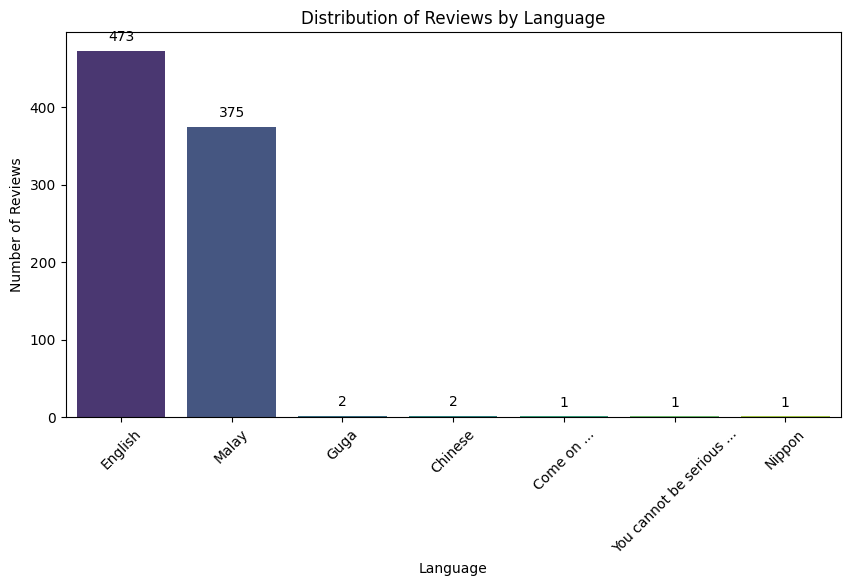

In [4]:
print(c["Language"].value_counts())

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=c,
    x="Language",
    order=c["Language"].value_counts().index,
    palette="viridis"
)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.title("Distribution of Reviews by Language")
plt.xlabel("Language")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)

plt.show()

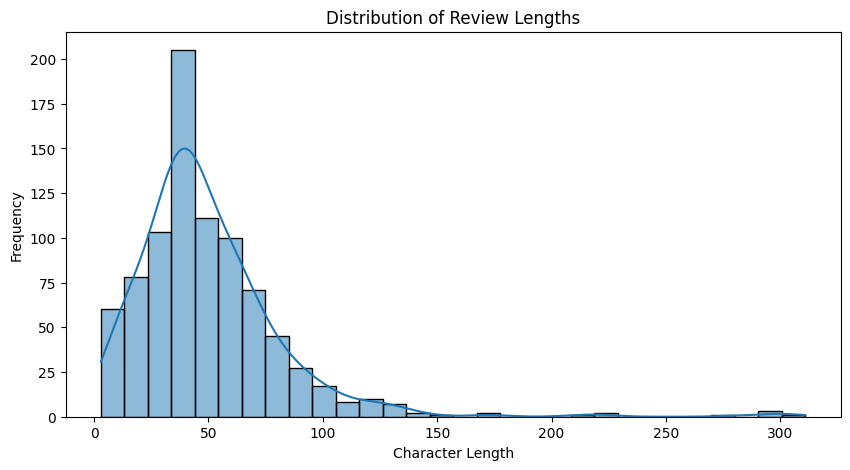

In [5]:
c["review_length"] = c["Review"].astype(str).apply(len)

plt.figure(figsize=(10,5))

sns.histplot(c["review_length"], bins=30, kde=True)

plt.title("Distribution of Review Lengths")
plt.xlabel("Character Length")
plt.ylabel("Frequency")

plt.show()

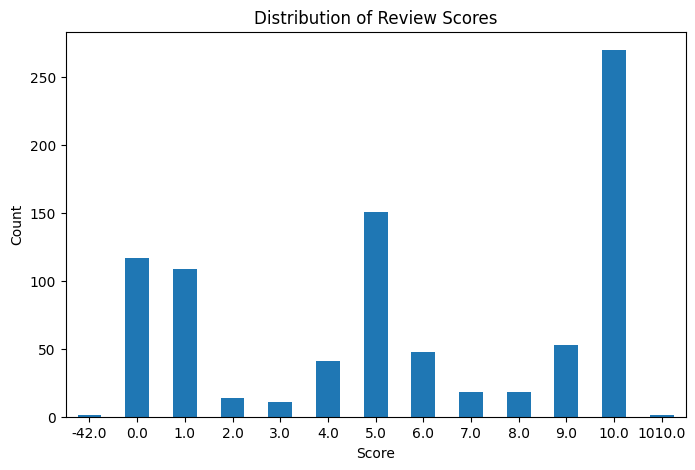

In [6]:
c['Score_Rounded'] = c['Score'].round()

plt.figure(figsize=(8,5))
c['Score_Rounded'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [7]:
c = c.dropna(subset=["Score"])

c = c[(c["Score"] >= 0) & (c["Score"] <= 10)]

valid_languages = ["English", "Malay"]

c = c[c["Language"].isin(valid_languages)]

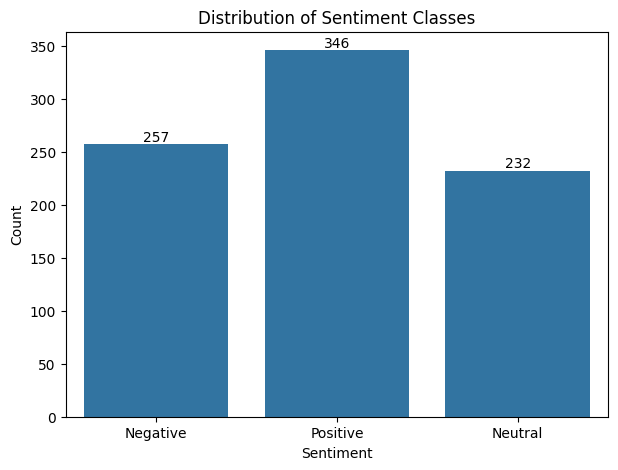

In [8]:
def sentiment_label(score):
    if score <= 4:
        return "Negative"
    elif score <= 7:
        return "Neutral"
    else:
        return "Positive"

c["Sentiment"] = c["Score"].apply(sentiment_label)

plt.figure(figsize=(7,5))

ax = sns.countplot(data=c, x="Sentiment")

ax.bar_label(ax.containers[0])

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Feature Engineering

Stopwords were retained because sequence-based models such as RNNs benefit from contextual information. Removing stopwords such as “not” may negatively affect sentiment interpretation.

# Translating

In [9]:
from googletrans import Translator
import time

translator = Translator()

def translate_malay(text):
    try:
        time.sleep(0.2)
        return translator.translate(text, src='ms', dest='en').text
    except:
        return text

mask = c['Language'] == 'Malay'
c.loc[mask, 'Review'] = c.loc[mask, 'Review'].apply(translate_malay)

c.to_csv("pizza_reviews_translated.csv", index=False)

print("Done")

Done


# reload csv

In [8]:
df = pd.read_csv("pizza_reviews_translated.csv")

def clean_text(text):

    text = text.lower()
    text = text.replace("’", "'")
    text = text.replace("didn't", "did not")
    text = text.replace("can't", "cannot")
    text = text.replace("won't", "will not")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_review"] = df["Review"].apply(clean_text)

# Tokenizer

In [9]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["clean_review"])

sequences = tokenizer.texts_to_sequences(df["clean_review"])

X = pad_sequences(sequences, maxlen=100)

# Encode Labels

In [10]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["Sentiment"])

# Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
comparison_df = pd.DataFrame({
    "Original Review": df["Review"].head(10),
    "Cleaned Review": df["clean_review"].head(10)
})

comparison_df

,Original Review,Cleaned Review
0,Disgusting.,disgusting
1,Loved the sambal kick!,loved the sambal kick
2,Loved the sambal kick!,loved the sambal kick
3,Loved the sambal kick!,loved the sambal kick
4,"Satay on pizza? Surprisingly worked. Tasty, un...",satay on pizza surprisingly worked tasty uniqu...
5,Mayo was too sweet. Didn't enjoy it at all.,mayo was too sweet did not enjoy it at all
6,"Spicy sambal was overwhelming for me, but the ...",spicy sambal was overwhelming for me but the s...
7,"Crust was soggy, and the satay sauce didn’t he...",crust was soggy and the satay sauce did not he...
8,Super creative! Sambal slice was fiery and bol...,super creative sambal slice was fiery and bold...
9,The sambal slice burned my mouth in the best w...,the sambal slice burned my mouth in the best w...


In [13]:
print("Original Review:")
print(df["clean_review"].iloc[0])

print("\nTokenized Sequence:")
print(sequences[0])

Original Review:
disgusting

Tokenized Sequence:
[139]


In [14]:
print("Sequence before padding:")
print(sequences[0])

print("\nLength before padding:")
print(len(sequences[0]))

print("\nSequence after padding:")
print(X[0])

print("\nLength after padding:")
print(len(X[0]))

Sequence before padding:
[139]

Length before padding:
1

Sequence after padding:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0 139]

Length after padding:
100


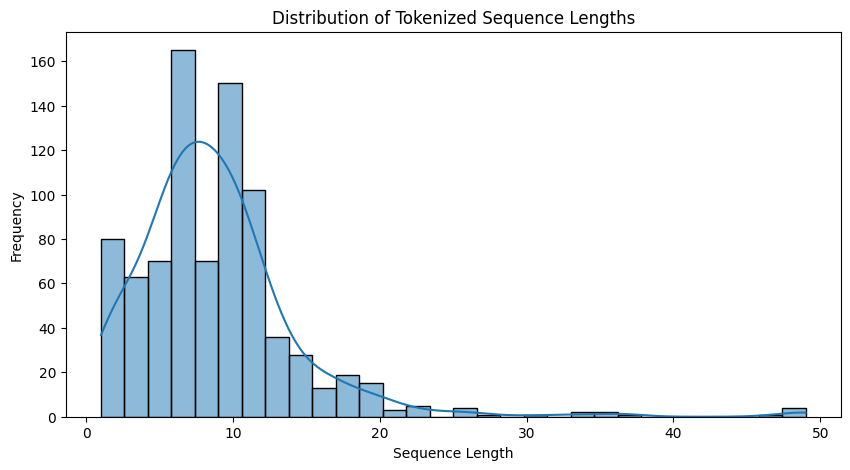

In [15]:
sequence_lengths = [len(seq) for seq in sequences]

plt.figure(figsize=(10,5))

sns.histplot(sequence_lengths, bins=30, kde=True)

plt.title("Distribution of Tokenized Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")

plt.show()

Vocabulary Size: 829
[('the', 448), ('and', 392), ('pizza', 300), ('is', 210), ('not', 183), ('of', 172), ('was', 169), ('sambal', 167), ('fusion', 155), ('taste', 143)]


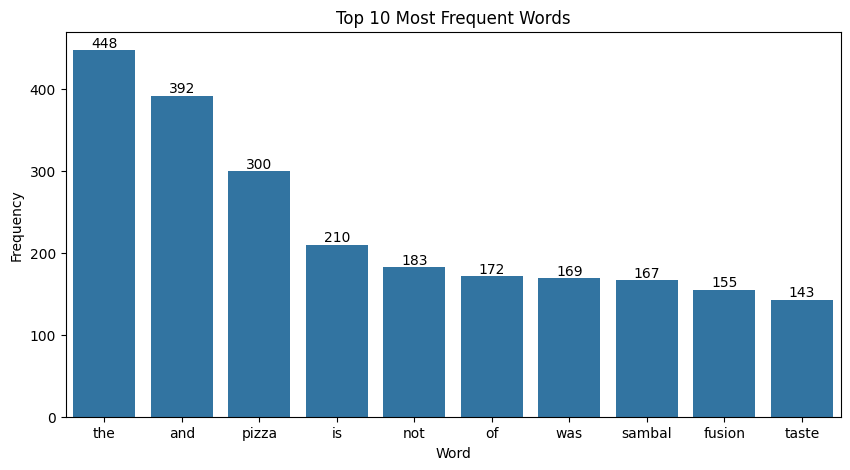

In [16]:
print("Vocabulary Size:", len(tokenizer.word_index))

word_counts = tokenizer.word_counts

top_words = sorted(
    word_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print(top_words)

top_words_df = pd.DataFrame(top_words, columns=["Word", "Count"])

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top_words_df,
    x="Word",
    y="Count"
)

ax.bar_label(ax.containers[0])

plt.title("Top 10 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()

# Simple RNN

In [17]:
vocab_size = 5000
max_len = 100
embedding_dim = 64

simple_rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),

    SimpleRNN(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

simple_rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']    
)

simple_rnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 64)           320000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                8256      
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 3)                 99        
                                                                 
Total params: 330,435
Trainable params: 330,435
Non-trainable params: 0
_________________________________________________________________


In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = simple_rnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

rnn_loss, rnn_acc = simple_rnn_model.evaluate(X_test, y_test)

print("SimpleRNN Accuracy:", rnn_acc)

Epoch 1/15
17/17 [==============================] - 1s 29ms/step - loss: 1.0849 - accuracy: 0.3895 - val_loss: 1.0510 - val_accuracy: 0.4179
Epoch 2/15
17/17 [==============================] - 0s 14ms/step - loss: 0.9791 - accuracy: 0.5337 - val_loss: 0.9592 - val_accuracy: 0.6045
Epoch 3/15
17/17 [==============================] - 0s 13ms/step - loss: 0.8263 - accuracy: 0.7097 - val_loss: 0.8332 - val_accuracy: 0.6940
Epoch 4/15
17/17 [==============================] - 0s 14ms/step - loss: 0.6326 - accuracy: 0.7978 - val_loss: 0.6834 - val_accuracy: 0.7388
Epoch 5/15
17/17 [==============================] - 0s 13ms/step - loss: 0.4254 - accuracy: 0.8783 - val_loss: 0.5406 - val_accuracy: 0.7836
Epoch 6/15
17/17 [==============================] - 0s 14ms/step - loss: 0.2613 - accuracy: 0.9326 - val_loss: 0.4742 - val_accuracy: 0.7910
Epoch 7/15
17/17 [==============================] - 0s 12ms/step - loss: 0.1872 - accuracy: 0.9532 - val_loss: 0.4561 - val_accuracy: 0.8582
Epoch 8/15
17

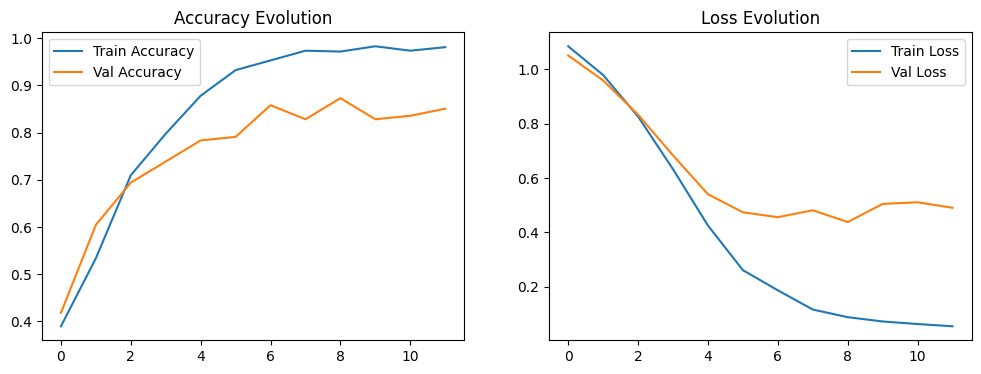

In [19]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

In [20]:
lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)

print("LSTM Accuracy:", lstm_acc)

Epoch 1/15
17/17 [==============================] - 2s 49ms/step - loss: 1.0833 - accuracy: 0.5468 - val_loss: 1.0483 - val_accuracy: 0.6343
Epoch 2/15
17/17 [==============================] - 1s 37ms/step - loss: 0.9882 - accuracy: 0.5899 - val_loss: 0.8712 - val_accuracy: 0.6493
Epoch 3/15
17/17 [==============================] - 0s 27ms/step - loss: 0.8011 - accuracy: 0.6798 - val_loss: 0.6933 - val_accuracy: 0.6716
Epoch 4/15
17/17 [==============================] - 0s 27ms/step - loss: 0.6368 - accuracy: 0.7004 - val_loss: 0.6223 - val_accuracy: 0.7612
Epoch 5/15
17/17 [==============================] - 0s 27ms/step - loss: 0.4940 - accuracy: 0.7884 - val_loss: 0.6340 - val_accuracy: 0.7985
Epoch 6/15
17/17 [==============================] - 0s 27ms/step - loss: 0.3761 - accuracy: 0.8577 - val_loss: 0.4785 - val_accuracy: 0.8507
Epoch 7/15
17/17 [==============================] - 0s 25ms/step - loss: 0.2915 - accuracy: 0.8933 - val_loss: 0.4759 - val_accuracy: 0.8881
Epoch 8/15
17

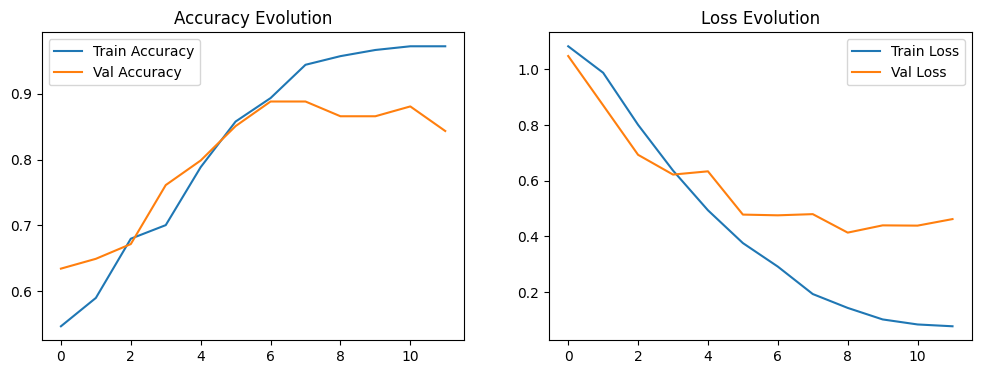

In [21]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

In [22]:
results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM"],
    "Accuracy": [rnn_acc, lstm_acc]
})

results

,Model,Accuracy
0,SimpleRNN,0.868263
1,LSTM,0.856287


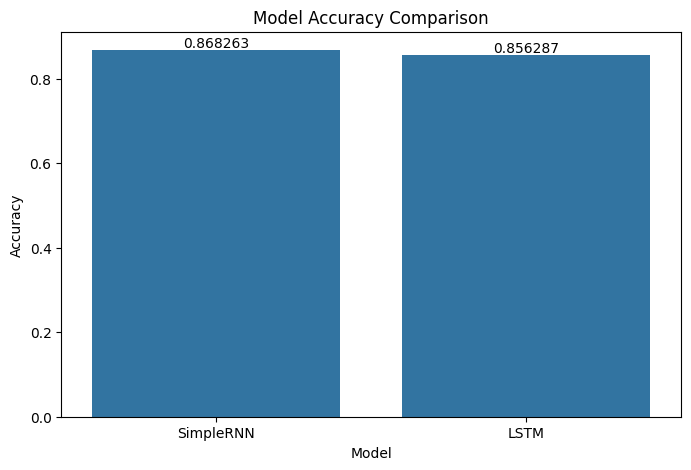

In [23]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

ax.bar_label(ax.containers[0])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# Model Improvement

## 1. Dropout

## 2. Bidirectional LSTM

## 3. Increase Embedding Size

## 4. Add more epochs + early stopping

## 5. Data Augmentation (later)

In [24]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

optimizer = Adam(learning_rate=0.0005)

improved_lstm = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_len
    ),

    Bidirectional(
        LSTM(
            32,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(0.001)
        )
    ),

    Dropout(0.4),

    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.2),

    Dense(3, activation='softmax')
])

improved_lstm.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)
checkpoint = ModelCheckpoint(
    filepath='best_neural_network_weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_improved = improved_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/30
17/17 [==============================] - ETA: 0s - loss: 1.2732 - accuracy: 0.4270
Epoch 1: val_accuracy improved from -inf to 0.38806, saving model to best_neural_network_weights.h5
17/17 [==============================] - 5s 95ms/step - loss: 1.2732 - accuracy: 0.4270 - val_loss: 1.2612 - val_accuracy: 0.3881 - lr: 5.0000e-04
Epoch 2/30
17/17 [==============================] - ETA: 0s - loss: 1.2443 - accuracy: 0.4213
Epoch 2: val_accuracy did not improve from 0.38806
17/17 [==============================] - 1s 59ms/step - loss: 1.2443 - accuracy: 0.4213 - val_loss: 1.2338 - val_accuracy: 0.3881 - lr: 5.0000e-04
Epoch 3/30
17/17 [==============================] - ETA: 0s - loss: 1.2094 - accuracy: 0.4213
Epoch 3: val_accuracy did not improve from 0.38806
17/17 [==============================] - 1s 75ms/step - loss: 1.2094 - accuracy: 0.4213 - val_loss: 1.1914 - val_accuracy: 0.3881 - lr: 5.0000e-04
Epoch 4/30
17/17 [==============================] - ETA: 0s - loss: 1.1517 

1. Bidirectional LSTM
Bidirectional(LSTM(64))

Allows the model to:

read sequences forward
AND backward

Example:

"not good"

Backward context helps sentiment understanding.

This is a strong NLP improvement.

2. Larger Embedding Dimension
embedding_dim = 128

Improves semantic representation of words.

Baseline:

64

Improved:

128
3. Dropout
Dropout(0.5)

Helps reduce overfitting.

Very important because the dataset is small.

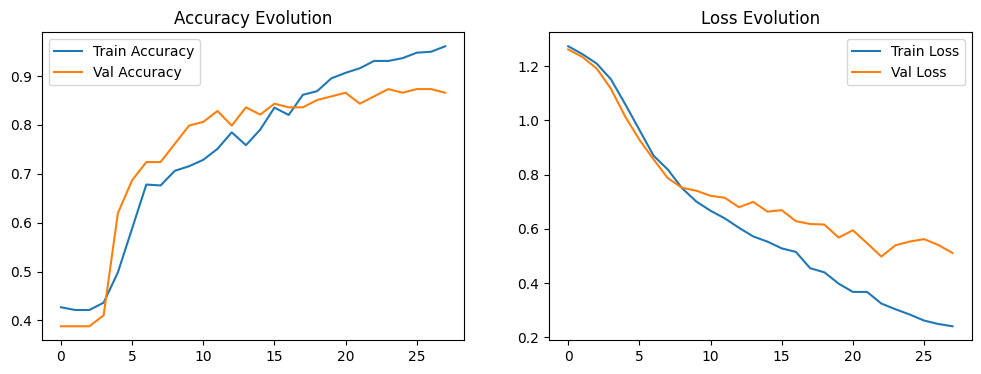

In [25]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

6/6 [==============================] - 0s 11ms/step
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        52
           1       0.81      0.85      0.83        46
           2       0.97      0.93      0.95        69

    accuracy                           0.87       167
   macro avg       0.86      0.86      0.86       167
weighted avg       0.87      0.87      0.87       167



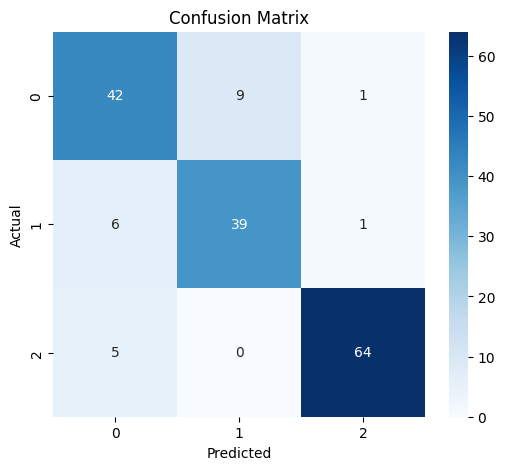

In [32]:
from sklearn.metrics import classification_report

predictions = improved_lstm.predict(X_test)

predicted_classes = predictions.argmax(axis=1)

print(classification_report(y_test, predicted_classes))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# AUGMENTATION

In [ ]:
def synonym_replacement(sentence, n=1):

    words = sentence.split()

    new_words = words.copy()

    random_word_list = list(set([
        word for word in words
        if len(word) > 3
    ]))

    random.shuffle(random_word_list)

    num_replaced = 0

    for random_word in random_word_list:

        synonyms = []

        for syn in wordnet.synsets(random_word):

            for lemma in syn.lemmas():

                synonym = lemma.name().replace("_", " ")

                if synonym != random_word:
                    synonyms.append(synonym)

        if len(synonyms) > 0:

            synonym = random.choice(list(set(synonyms)))

            new_words = [
                synonym if word == random_word else word
                for word in new_words
            ]

            num_replaced += 1

        if num_replaced >= n:
            break

    return " ".join(new_words)


X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_review"],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

augmented_train_reviews = [
    synonym_replacement(text, n=1)
    for text in X_train_text
]


combined_train_reviews = (
    list(X_train_text) +
    augmented_train_reviews
)

combined_train_labels = np.concatenate([
    y_train,
    y_train
])

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(combined_train_reviews)

train_sequences = tokenizer.texts_to_sequences(
    combined_train_reviews
)

X_train_aug = pad_sequences(
    train_sequences,
    maxlen=max_len
)


test_sequences = tokenizer.texts_to_sequences(
    X_test_text
)

X_test_aug = pad_sequences(
    test_sequences,
    maxlen=max_len
)


print("Training Shape:", X_train_aug.shape)
print("Test Shape:", X_test_aug.shape)

print("Training Labels:", combined_train_labels.shape)
print("Test Labels:", y_test.shape)

Training Shape: (1336, 100)
Test Shape: (167, 100)
Training Labels: (1336,)
Test Labels: (167,)


In [34]:
optimizer = Adam(learning_rate=0.0005)

augmented_lstm = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_len
    ),

    Bidirectional(
        LSTM(
            32,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(0.001)
        )
    ),

    Dropout(0.4),

    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.2),

    Dense(3, activation='softmax')
])

augmented_lstm.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)
checkpoint = ModelCheckpoint(
    filepath='best_neural_network_weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

y_train_aug = combined_train_labels 
history_augmented = augmented_lstm.fit(
    X_train_aug, 
    y_train_aug,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
34/34 [==============================] - ETA: 0s - loss: 1.2686 - accuracy: 0.4167
Epoch 1: val_accuracy improved from -inf to 0.47015, saving model to best_neural_network_weights.h5
34/34 [==============================] - 6s 77ms/step - loss: 1.2686 - accuracy: 0.4167 - val_loss: 1.2392 - val_accuracy: 0.4701 - lr: 5.0000e-04
Epoch 2/20
34/34 [==============================] - ETA: 0s - loss: 1.2189 - accuracy: 0.4635
Epoch 2: val_accuracy improved from 0.47015 to 0.51493, saving model to best_neural_network_weights.h5
34/34 [==============================] - 2s 65ms/step - loss: 1.2189 - accuracy: 0.4635 - val_loss: 1.1756 - val_accuracy: 0.5149 - lr: 5.0000e-04
Epoch 3/20
34/34 [==============================] - ETA: 0s - loss: 1.1425 - accuracy: 0.5534
Epoch 3: val_accuracy improved from 0.51493 to 0.65299, saving model to best_neural_network_weights.h5
34/34 [==============================] - 2s 62ms/step - loss: 1.1425 - accuracy: 0.5534 - val_loss: 1.0524 - val_accur

6/6 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

           0       0.91      0.81      0.86        52
           1       0.79      0.91      0.85        46
           2       0.96      0.94      0.95        69

    accuracy                           0.89       167
   macro avg       0.89      0.89      0.88       167
weighted avg       0.90      0.89      0.89       167



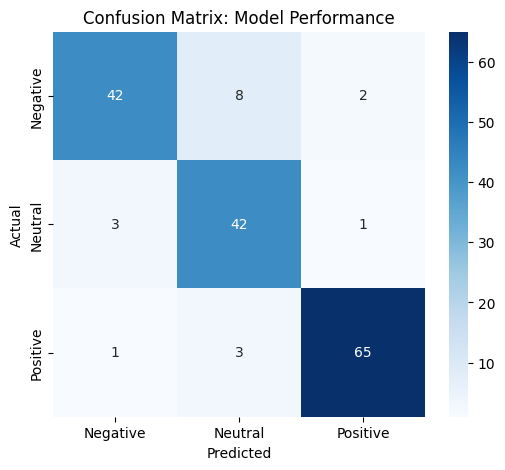

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns

# # 1. Get predictions
# y_pred_probs = augmented_lstm.predict(X_test_aug)
# y_pred = np.argmax(y_pred_probs, axis=1)

# print(classification_report(y_test, y_pred))

# # 3. Plot Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['Negative', 'Neutral', 'Positive'], 
#             yticklabels=['Negative', 'Neutral', 'Positive'])
# plt.ylabel('Actual')
# plt.xlabel('Predicted')
# plt.title('Confusion Matrix: Model Performance')
# plt.show()

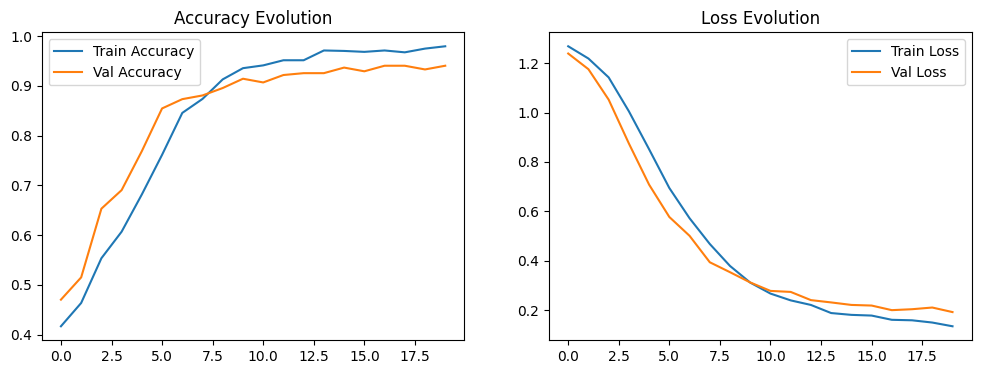

In [37]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_augmented.history['accuracy'], label='Train Accuracy')
plt.plot(history_augmented.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_augmented.history['loss'], label='Train Loss')
plt.plot(history_augmented.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

In [1]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = augmented_lstm.predict(X_test_aug)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Model Performance')
plt.show()

NameError: name 'augmented_lstm' is not defined